# VRPN mocap streaming exploration

Goal: **understand exactly what the Nokov (XINGYING) server broadcasts over VRPN
and how to access each piece** — rigid bodies, markers, skeletons; their origin,
orientation, per-segment / per-marker data — by probing it step by step.

This notebook goes through the project's VRPN pipeline
([`vrpn_dependencies.py`](vrpn_dependencies.py) → `VRPNRigidBodyReader`) plus the
raw `vrpn` binding so you can see the data dicts directly.

## What the Nokov docs say (the model we'll verify empirically)

- The Nokov server broadcasts on **VRPN port 3883** (no auth — only the server IP,
  like the SDK).
- Each **Markerset** in XINGYING is published as a **VRPN _tracker_ (sender)
  named after the Markerset** (e.g. a Markerset called `CubeInCube2` → tracker
  `CubeInCube2@10.1.1.198`).
- **Pose = Position + Orientation.** Orientation (quaternion) is sent **only when
  the Markerset type is "Rigid Body"**. Plain markers stream position only
  (orientation is identity / meaningless).
- A **rigid body needs ≥3 markers**; up to 100 rigid bodies are supported.
- **Skeletons ("Body")**: human models have 16–63 keypoints (e.g. 53-pt "Baseline
  + Toe, Headband"). The docs note *"the human skeleton … has no specified
  orientation"* — segment orientation depends on the model and the per-segment
  "Bone Axis" setting. **Whether each skeleton segment is exposed as its own
  VRPN tracker, or as multiple _sensors_ on one tracker, is exactly what we probe
  below** (steps 2–3).
- VRPN positions are in **meters** here (XINGYING's VRPN unit is set to meters;
  the SDK path uses mm). Quaternions arrive as **(x, y, z, w)**.

Sources:
[VRPN Protocol Method](https://docs.nokov.com/robot-comm/robot-comm-en-docs/si-ros2-tong-xin/yi-vrpn-xie-yi-fang-shi/) ·
[Create MarkerSet (Rigid)](https://docs.nokov.com/xingying/XingYing3.4-EN/data-edit/-create-markerset-rigid/) ·
[Body / skeleton markersets](https://docs.nokov.com/xingying/XingYing4.1-EN/create-markerset/-body/) ·
[Use VRPN data to drive a rigid body in UE](https://xingying3x-en-docs.nokov.com/readme/xvii.-plugins-and-sdk/3.-use-vrpn-data-to-drive-rigid-body-in-ue)

> Run cells top-to-bottom **while on the mocap subnet** (`10.1.1.0/24`, server at
> `10.1.1.198`) with XINGYING playing and VRPN enabled.

## Step 0 — config & imports

`vrpn` is installed in the venv; we fall back to the vendored binding if not.
We also pull the project's `discover_senders` / `VRPNRigidBodyReader`.

In [2]:
import shutil
import subprocess
import sys
import time
from pathlib import Path

# --- config -----------------------------------------------------------------
SERVER_IP = "10.1.1.198"          # Nokov VRPN server
PORT = 3883
HOST = SERVER_IP if PORT == 3883 else f"{SERVER_IP}:{PORT}"
RIGID_BODY_NAME = "CubInCube2"    # NOTE: server spells it "CubInCube2" (no 'e')

# --- import the vrpn binding (venv first, vendored fallback) ----------------
try:
    import vrpn
except ImportError:
    here = Path.cwd().resolve()
    repo = next((p for p in [here, *here.parents]
                 if (p / "motion_capture").is_dir()), here)
    sys.path.insert(0, str(repo / "motion_capture"
                           / "nokov_python_vrpn-master" / "dist"))
    import vrpn
print("vrpn module :", vrpn.__file__)

# --- import the project pipeline --------------------------------------------
here = Path.cwd().resolve()
repo = next((p for p in [here, *here.parents]
             if (p / "motion_capture").is_dir()), here)
sys.path.insert(0, str(repo))
from motion_capture.mymocap.vrpn_dependencies import (
    VRPNRigidBodyReader,
    _DISCOVER_BIN,
    discover_senders,
)
print("project reader: VRPNRigidBodyReader loaded")
print("HOST         :", HOST)

vrpn module : /home/matthias-weiss/dev/zhaw/robotics/my_mujoco_playground/.venv/lib/python3.10/site-packages/vrpn.so
project reader: VRPNRigidBodyReader loaded
HOST         : 10.1.1.198


## Step 1 — discover what the server publishes (senders + message types)

The `discover_senders` helper connects, pumps the control channel ~3 s, then
lists **every sender** (each rigid body / marker / skeleton tracker) **and every
message type** the connection knows. Senders = the names you can subscribe to;
message types tell you which VRPN channels exist (e.g. `vrpn_Tracker Pos_Quat`,
`… Velocity`, `… Acceleration`).

In [3]:
bin_path = shutil.which("discover_senders") or (str(_DISCOVER_BIN) if _DISCOVER_BIN else "")
print("discover helper:", bin_path or "NOT FOUND")
proc = subprocess.run([bin_path, HOST], capture_output=True, text=True, timeout=15)
print(proc.stdout)
if proc.stderr:
    print("[stderr]", proc.stderr)

discover helper: /home/matthias-weiss/dev/zhaw/robotics/my_mujoco_playground/.venv/bin/discover_senders
Connecting to 10.1.1.198 ...
connected=1
Senders:
  [0] VRPN Control
  [1] CubeInCube_Marker1
  [2] CubeInCube_Marker2
  [3] CubeInCube_Marker3
  [4] PUBeam_11_Marker1
  [5] PUBeam_11_Marker10
  [6] PUBeam_11_Marker11
  [7] PUBeam_11_Marker2
  [8] PUBeam_11_Marker3
  [9] PUBeam_11_Marker4
  [10] PUBeam_11_Marker5
  [11] PUBeam_11_Marker6
  [12] PUBeam_11_Marker7
  [13] PUBeam_11_Marker8
  [14] PUBeam_11_Marker9
  [15] CubInCube2
  [16] CubInCube2_Marker1
  [17] CubInCube2_Marker2
  [18] CubInCube2_Marker3
  [19] PUBeam_11
  [20] Tracker0
  [21] CubeInCube2
Message types:
  [0] VRPN_Connection_Got_First_Connection
  [1] VRPN_Connection_Got_Connection
  [2] VRPN_Connection_Dropped_Connection
  [3] VRPN_Connection_Dropped_Last_Connection
  [4] vrpn_Tracker Pos_Quat
  [5] vrpn_Tracker Velocity
  [6] vrpn_Tracker Acceleration
  [7] vrpn_Tracker To_Room
  [8] vrpn_Tracker Unit_To_Sensor
  

**Read this output carefully — it answers most of the questions:**

- Under **`Senders:`** you'll see one entry per streamable thing. A rigid body
  Markerset (e.g. `CubeInCube2`) and each individual marker show up here. If a
  **skeleton** is published per-segment-as-tracker, you'll see many entries with
  a shared prefix (e.g. `Skeleton_Hip`, `Skeleton_Spine`, …). If a skeleton is
  published as **one tracker with many sensors**, you'll see a single skeleton
  name here and the multiple sensors appear in Step 3.
- Under **`Message types:`** look for `vrpn_Tracker Pos_Quat` (position +
  orientation). If you also see `Velocity` / `Acceleration` types, those channels
  exist and Step 4 will pick them up.

In [4]:
# Clean name list via the project helper (excludes the internal 'VRPN Control').
senders = discover_senders(SERVER_IP, PORT)
print(f"{len(senders)} subscribable sender(s):")
for nm in sorted(senders):
    print("   ", nm)
if senders and RIGID_BODY_NAME not in senders:
    print(f"\n[!] '{RIGID_BODY_NAME}' is NOT one of the senders above — "
          "set RIGID_BODY_NAME in Step 0 to one of these names.")

21 subscribable sender(s):
    CubInCube2
    CubInCube2_Marker1
    CubInCube2_Marker2
    CubInCube2_Marker3
    CubeInCube2
    CubeInCube_Marker1
    CubeInCube_Marker2
    CubeInCube_Marker3
    PUBeam_11
    PUBeam_11_Marker1
    PUBeam_11_Marker10
    PUBeam_11_Marker11
    PUBeam_11_Marker2
    PUBeam_11_Marker3
    PUBeam_11_Marker4
    PUBeam_11_Marker5
    PUBeam_11_Marker6
    PUBeam_11_Marker7
    PUBeam_11_Marker8
    PUBeam_11_Marker9
    Tracker0


## Step 2 — raw dump of ONE tracker: see every field that's sent

Subscribe to `RIGID_BODY_NAME` with a `position` change handler that captures the
**entire data dict**, so we can see exactly which keys VRPN delivers and what they
look like. Drive it by calling `tracker.mainloop()` in a loop.

In [5]:
import pprint

captured = []
def dump_handler(userdata, data):
    captured.append(data)

t = vrpn.receiver.Tracker(f"{RIGID_BODY_NAME}@{HOST}")
t.register_change_handler("dump", dump_handler, "position")

print(f"pumping '{RIGID_BODY_NAME}' for up to 3 s ...")
t_end = time.time() + 3.0
while time.time() < t_end and len(captured) < 5:
    t.mainloop()
    time.sleep(0.001)
print(f"received {len(captured)} position report(s)\n")

if captured:
    print("=== keys in a position report ===")
    print(list(captured[0].keys()))
    print("\n=== first report (full) ===")
    pprint.pprint(captured[0])
else:
    print("No reports. Is the body visible to the cameras and VRPN enabled?")

pumping 'CubInCube2' for up to 3 s ...
received 5 position report(s)

=== keys in a position report ===
['time', 'sensor', 'position', 'quaternion']

=== first report (full) ===
{'position': (-0.7657499313354492, -0.11010530591011047, 0.6081150770187378),
 'quaternion': (-0.273094117641449,
                0.028214119374752045,
                0.005902855657041073,
                0.9615553617477417),
 'sensor': 0,
 'time': datetime.datetime(2026, 6, 12, 12, 49, 43, 992670)}


check_vrpn_cookie(): VRPN Note: minor version number doesn't match: (prefer 'vrpn: ver. 07.38', got 'vrpn: ver. 07.34  0').  This is not normally a problem.


**How to read a position report** (the keys above):

| key          | meaning                                                            |
|--------------|--------------------------------------------------------------------|
| `time`       | server timestamp of the sample                                     |
| `sensor`     | channel index **within this tracker** — `0` for a single rigid body; a skeleton uses one index **per segment** (see Step 3) |
| `position`   | `(x, y, z)` of the body **origin/centerpoint**, in **meters**      |
| `quaternion` | orientation `(x, y, z, w)` — **only meaningful for Rigid Body type** |

So: **origin** = `position`; **orientation** = `quaternion` (reorder to
`w,x,y,z` for our obs builder). This is the per-body "midpoint + orientation"
you wanted to stream.

## Step 3 — sensor channels: is this a single body or a multi-segment skeleton?

A VRPN tracker can carry **many sensors**. A rigid body reports only `sensor 0`.
A **skeleton streamed as one tracker** reports a **different `sensor` index per
segment**. Pump the chosen tracker and tally the distinct sensor ids — that tells
you whether you're looking at a single rigid body or a segmented skeleton, and how
many segments it has.

In [6]:
sensors_seen = {}   # sensor_id -> (count, last position, last quat)
def sensor_probe(userdata, data):
    s = data["sensor"]
    cnt = sensors_seen.get(s, (0, None, None))[0] + 1
    sensors_seen[s] = (cnt, data["position"], data["quaternion"])

tp = vrpn.receiver.Tracker(f"{RIGID_BODY_NAME}@{HOST}")
tp.register_change_handler("probe", sensor_probe, "position")
print(f"probing sensors on '{RIGID_BODY_NAME}' for 3 s ...")
t_end = time.time() + 3.0
while time.time() < t_end:
    tp.mainloop()
    time.sleep(0.001)

print(f"\ndistinct sensor id(s): {sorted(sensors_seen)}")
for s in sorted(sensors_seen):
    cnt, pos, quat = sensors_seen[s]
    print(f"  sensor {s}: {cnt} reports | pos {pos} | quat(xyzw) {quat}")
print("\n=> 1 sensor (id 0) => single RIGID BODY."
      "\n=> many sensors    => SKELETON, one sensor per segment "
      "(each with its own origin + quaternion).")

probing sensors on 'CubInCube2' for 3 s ...



distinct sensor id(s): [0]
  sensor 0: 182 reports | pos (-0.7657514810562134, -0.11009549349546432, 0.6081164479255676) | quat(xyzw) (-0.2732919156551361, 0.028059164062142372, 0.006166879553347826, 0.9615020155906677)

=> 1 sensor (id 0) => single RIGID BODY.
=> many sensors    => SKELETON, one sensor per segment (each with its own origin + quaternion).


**Streaming a skeleton + its segment orientations:** if Step 3 shows multiple
sensors, you stream the whole skeleton from this *one* tracker and split by
`sensor` index inside the handler — each sensor is a segment with its own
`position` and `quaternion`. (Per Nokov, segment orientation is only well-defined
when the Bone Axis is set; some human-skeleton models report identity orientation.)
If instead each segment is its own **sender** (Step 1 showed many prefixed names),
you subscribe to each segment name separately, exactly like a rigid body.

## Step 4 — does Nokov send velocity / acceleration too?

The `vrpn` Tracker also exposes `velocity` and `acceleration` change handlers.
Register all three and see which actually deliver reports — most Nokov VRPN
setups send only position+orientation, but this confirms it for *your* server.

In [7]:
vel, acc, pos = [], [], []
t3 = vrpn.receiver.Tracker(f"{RIGID_BODY_NAME}@{HOST}")
t3.register_change_handler("p", lambda u, d: pos.append(d), "position")
t3.register_change_handler("v", lambda u, d: vel.append(d), "velocity")
t3.register_change_handler("a", lambda u, d: acc.append(d), "acceleration")

print("pumping all three channels for 3 s ...")
t_end = time.time() + 3.0
while time.time() < t_end:
    t3.mainloop()
    time.sleep(0.001)

print(f"position    : {len(pos)} reports")
print(f"velocity    : {len(vel)} reports")
print(f"acceleration: {len(acc)} reports")
if vel:
    print("\nvelocity report keys:", list(vel[0].keys()))
if acc:
    print("acceleration report keys:", list(acc[0].keys()))

pumping all three channels for 3 s ...
position    : 182 reports
velocity    : 182 reports
acceleration: 182 reports

velocity report keys: ['time', 'sensor', 'velocity', 'future quaternion', 'future delta']
acceleration report keys: ['time', 'sensor', 'acceleration', 'future acceleration ?', 'future delta']


## Step 5 — full scene inventory via the project reader (stream ALL)

`VRPNRigidBodyReader(names=None)` discovers every sender and subscribes to all of
them (the "stream everything" mode). After a couple of seconds, dump the latest
pose of each reporting body — the complete picture of what's live right now.

In [8]:
reader = VRPNRigidBodyReader(SERVER_IP, names=None, port=PORT)
ok = reader.start(timeout=8.0)
print("subscribed:", reader._names if ok else "FAILED")
reader.wait_for_data(timeout=5.0)
time.sleep(2.0)

bodies = reader.get_body()   # {name: {"xyz": np(3), "quat": np(4) wxyz}}
print(f"\n{len(bodies)}/{len(reader._names)} tracker(s) reporting:\n")
for nm in sorted(bodies):
    p = bodies[nm]["xyz"]; q = bodies[nm]["quat"]
    print(f"  {nm:28s} xyz(m) {p[0]:7.3f} {p[1]:7.3f} {p[2]:7.3f}"
          f"  quat(wxyz) {q[0]:6.3f} {q[1]:6.3f} {q[2]:6.3f} {q[3]:6.3f}")
reader.stop()
print("\nstopped.")

[VRPN] Connecting to 10.1.1.198:3883 ...
[VRPN] ✓ Subscribed to 21 tracker(s): ['CubeInCube_Marker1', 'CubeInCube_Marker2', 'CubeInCube_Marker3', 'PUBeam_11_Marker1', 'PUBeam_11_Marker10', 'PUBeam_11_Marker11', 'PUBeam_11_Marker2', 'PUBeam_11_Marker3', 'PUBeam_11_Marker4', 'PUBeam_11_Marker5', 'PUBeam_11_Marker6', 'PUBeam_11_Marker7', 'PUBeam_11_Marker8', 'PUBeam_11_Marker9', 'CubInCube2', 'CubInCube2_Marker1', 'CubInCube2_Marker2', 'CubInCube2_Marker3', 'PUBeam_11', 'Tracker0', 'CubeInCube2']
subscribed: ['CubeInCube_Marker1', 'CubeInCube_Marker2', 'CubeInCube_Marker3', 'PUBeam_11_Marker1', 'PUBeam_11_Marker10', 'PUBeam_11_Marker11', 'PUBeam_11_Marker2', 'PUBeam_11_Marker3', 'PUBeam_11_Marker4', 'PUBeam_11_Marker5', 'PUBeam_11_Marker6', 'PUBeam_11_Marker7', 'PUBeam_11_Marker8', 'PUBeam_11_Marker9', 'CubInCube2', 'CubInCube2_Marker1', 'CubInCube2_Marker2', 'CubInCube2_Marker3', 'PUBeam_11', 'Tracker0', 'CubeInCube2']

15/21 tracker(s) reporting:

  CubInCube2                   xyz(m)  

## Step 6 — stream just `CubeInCube2`: origin + orientation (+ offset)

This is the deployment case: subscribe to **only** the one body, read its origin
and orientation, and optionally apply a **body-frame offset** (rotates with the
cube) via the new `get_offset_pose()` helper.

In [9]:
reader = VRPNRigidBodyReader(
    SERVER_IP,
    rigid_body_name=RIGID_BODY_NAME,
    names=[RIGID_BODY_NAME],     # subscribe to ONLY this body
    port=PORT,
    offset=[0.0, 0.0, 0.03],     # e.g. 3 cm above the cube, in the cube's frame
)
reader.start(timeout=8.0)
reader.wait_for_data(timeout=5.0)

for _ in range(10):
    raw_xyz, raw_q = reader.get_rigid_body_pose()    # true origin + orientation
    off_xyz, off_q = reader.get_offset_pose()        # origin + body-frame offset
    if raw_xyz is not None:
        print(f"origin {raw_xyz.round(3)}  quat(wxyz) {raw_q.round(3)}  "
              f"|  +offset {off_xyz.round(3)}")
    time.sleep(0.2)
reader.stop()

[VRPN] Connecting to 10.1.1.198:3883 ...
[VRPN] ✓ Subscribed to 1 tracker(s): ['CubInCube2']
origin [-0.766 -0.11   0.608]  quat(wxyz) [ 0.962 -0.273  0.028  0.006]  |  +offset [-0.764 -0.094  0.634]
origin [-0.766 -0.11   0.608]  quat(wxyz) [ 0.962 -0.273  0.03   0.006]  |  +offset [-0.764 -0.094  0.633]
origin [-0.766 -0.11   0.608]  quat(wxyz) [ 0.962 -0.273  0.028  0.006]  |  +offset [-0.764 -0.094  0.634]
origin [-0.766 -0.11   0.608]  quat(wxyz) [ 0.962 -0.273  0.028  0.006]  |  +offset [-0.764 -0.094  0.634]
origin [-0.766 -0.11   0.608]  quat(wxyz) [ 0.962 -0.273  0.029  0.006]  |  +offset [-0.764 -0.094  0.634]
origin [-0.766 -0.11   0.608]  quat(wxyz) [ 0.962 -0.273  0.029  0.006]  |  +offset [-0.764 -0.094  0.634]
origin [-0.766 -0.11   0.608]  quat(wxyz) [ 0.962 -0.273  0.029  0.006]  |  +offset [-0.764 -0.094  0.634]
origin [-0.766 -0.11   0.608]  quat(wxyz) [ 0.961 -0.273  0.029  0.006]  |  +offset [-0.764 -0.094  0.633]
origin [-0.766 -0.11   0.608]  quat(wxyz) [ 0.962 -

## Step 7 — realtime 3D view of `CubInCube2`

Live 3D plot of the streamed centerpoint: a **4 cm cube** drawn around the body
origin, a **body-frame XYZ triad** (X red, Y green, Z blue) showing its
orientation from the quaternion, and the live `center` / `quat` in the title.
The view auto-centers on the cube so the 4 cm box stays visible while it moves.

Redraws at `FPS` Hz via `clear_output`+`display` (works in VSCode / classic
Jupyter, no extra backend). Set `ORIENT_CUBE = False` to draw an axis-aligned
cube + world axes instead. Interrupt the kernel to stop early.

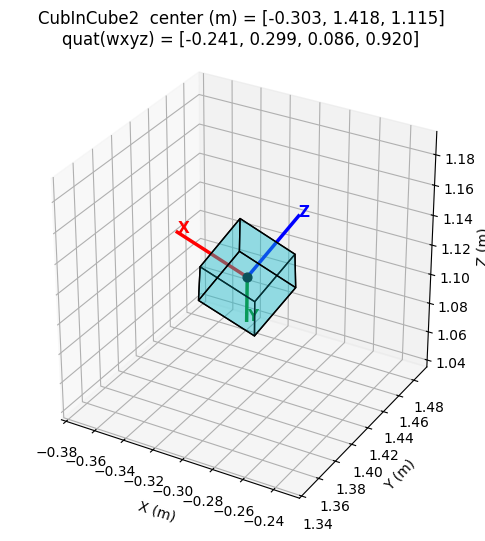

stopped.


In [15]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from IPython.display import clear_output, display

# --- view / stream settings -------------------------------------------------
DURATION = 20.0      # seconds to stream the live view
FPS = 10             # redraw rate (Hz)
CUBE_SIZE = 0.04     # 4 cm cube drawn around the streamed centerpoint
AXIS_LEN = 0.05      # length of the body-frame XYZ triad at the cube center
VIEW_HALF = 0.08     # half-span of the 3D view box around the cube (meters)
ORIENT_CUBE = True   # rotate the cube + triad by the streamed quaternion

# 8 corners of a cube centered at origin, in the body frame.
_HALF = CUBE_SIZE / 2.0
_CORNERS = _HALF * np.array(
    [[sx, sy, sz] for sx in (-1, 1) for sy in (-1, 1) for sz in (-1, 1)],
    dtype=float,
)
_FACES = [(0, 1, 3, 2), (4, 5, 7, 6), (0, 1, 5, 4),
          (2, 3, 7, 6), (0, 2, 6, 4), (1, 3, 7, 5)]


def _quat_wxyz_to_R(q):
    """Rotation matrix from a (w, x, y, z) quaternion."""
    w, x, y, z = q
    return np.array([
        [1 - 2 * (y * y + z * z), 2 * (x * y - w * z), 2 * (x * z + w * y)],
        [2 * (x * y + w * z), 1 - 2 * (x * x + z * z), 2 * (y * z - w * x)],
        [2 * (x * z - w * y), 2 * (y * z + w * x), 1 - 2 * (x * x + y * y)],
    ])


reader = VRPNRigidBodyReader(
    SERVER_IP, rigid_body_name=RIGID_BODY_NAME,
    names=[RIGID_BODY_NAME], port=PORT,
)
reader.start(timeout=8.0)
if not reader.wait_for_data(timeout=5.0):
    print(f"No data for '{RIGID_BODY_NAME}' — is it visible to the cameras?")

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
t_end = time.time() + DURATION
try:
    while time.time() < t_end:
        xyz, quat = reader.get_rigid_body_pose()
        if xyz is None:
            time.sleep(1.0 / FPS)
            continue
        R = _quat_wxyz_to_R(quat) if ORIENT_CUBE else np.eye(3)

        ax.clear()
        # 4 cm cube around the centerpoint (rotated by the body's orientation).
        corners = (R @ _CORNERS.T).T + xyz
        faces = [[corners[i] for i in f] for f in _FACES]
        ax.add_collection3d(Poly3DCollection(
            faces, facecolor="tab:cyan", edgecolor="k", alpha=0.25, lw=1.0))
        # Body-frame XYZ triad at the cube center: X red, Y green, Z blue.
        for vec, col, lbl in zip(R.T, ("r", "g", "b"), ("X", "Y", "Z")):
            tip = xyz + AXIS_LEN * vec
            ax.plot(*zip(xyz, tip), color=col, lw=2.5)
            ax.text(*tip, lbl, color=col, fontsize=11, fontweight="bold")
        # Centerpoint marker.
        ax.scatter(*xyz, color="k", s=40)

        ax.set_xlim(xyz[0] - VIEW_HALF, xyz[0] + VIEW_HALF)
        ax.set_ylim(xyz[1] - VIEW_HALF, xyz[1] + VIEW_HALF)
        ax.set_zlim(xyz[2] - VIEW_HALF, xyz[2] + VIEW_HALF)
        ax.set_box_aspect((1, 1, 1))
        ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)"); ax.set_zlabel("Z (m)")
        ax.set_title(
            f"{RIGID_BODY_NAME}  center (m) = "
            f"[{xyz[0]:.3f}, {xyz[1]:.3f}, {xyz[2]:.3f}]\n"
            f"quat(wxyz) = [{quat[0]:.3f}, {quat[1]:.3f}, "
            f"{quat[2]:.3f}, {quat[3]:.3f}]")

        clear_output(wait=True)
        display(fig)
        time.sleep(1.0 / FPS)
except KeyboardInterrupt:
    pass
finally:
    reader.stop()
    plt.close(fig)
    print("stopped.")

## Summary — answers to the questions

- **What is streamed?** Every XINGYING Markerset is a VRPN **tracker (sender)**
  named after the Markerset (Step 1). Each position report carries
  `time, sensor, position (x,y,z meters), quaternion (x,y,z,w)` (Step 2).
- **Origin & orientation of a body:** `position` is the origin/centerpoint;
  `quaternion` is the orientation — meaningful **only for Rigid Body** markersets.
  Use `get_rigid_body_pose()` / `get_offset_pose()` (Step 6).
- **Can I stream skeletons?** Yes. A skeleton is published either as **one tracker
  with one `sensor` per segment** (split by `sensor` in the handler — Step 3) or as
  **many per-segment senders** (subscribe to each, like rigid bodies — Step 1).
- **Skeleton orientation?** Each segment carries a quaternion, but per Nokov the
  human skeleton has *no specified orientation* unless the per-segment **Bone Axis**
  is set; some models report identity. Verify with Step 3's per-sensor quats.
- **Each marker?** Individual markers appear as their own senders (Step 1),
  position-only (orientation identity).
- **Velocity / acceleration?** Only if Step 4 reports them — usually position+pose
  only.

**To map a body into the 26-D obs** (`box_xmat[:6]`), take `get_rigid_body_quat()`
(already reordered to `w,x,y,z`) and convert via the `quat_to_xmat_flat()` helper
in `robots/UR3e/ur3_realrobot_dependencies.py`.